In [135]:
import os
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from wordcloud import WordCloud
from google.colab import drive
from wordcloud import WordCloud, STOPWORDS
from plotly.subplots import make_subplots
from itertools import combinations
from collections import Counter

In [126]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
root_path = '/content/drive/MyDrive/notebooks'

if not os.path.exists(root_path):
    os.makedirs(root_path)

os.chdir(root_path)
print(f"Current work folder: {os.getcwd()}")

Current work folder: /content/drive/MyDrive/notebooks


In [128]:
data_dir = os.path.join(root_path, 'crawler_data')

files = [
    'companies.csv',
    'companies_embeddings.csv',
    'jobs.csv',
    'jobs_embeddings.csv',
    'skills.csv',
    'skills_jobs.csv'
]

dataframes = {}

for file in files:
    file_path = os.path.join(data_dir, file)
    if os.path.exists(file_path):
        df_name = file.replace('.csv', '')
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"Loaded {file} successfully.")
    else:
        print(f"Warning: {file} not found in {data_dir}")

if 'companies' in dataframes:
  companies_df = dataframes['companies']
if 'companies_embeddings' in dataframes:
  companies_embeddings_df = dataframes['companies_embeddings']
if 'jobs' in dataframes:
  jobs_df = dataframes['jobs']
if 'jobs_embeddings' in dataframes:
  jobs_embeddings_df = dataframes['jobs_embeddings']
if 'skills' in dataframes:
  skills_df = dataframes['skills']
if 'skills_jobs' in dataframes:
  skills_jobs_df = dataframes['skills_jobs']

Loaded companies.csv successfully.
Loaded companies_embeddings.csv successfully.
Loaded jobs.csv successfully.
Loaded jobs_embeddings.csv successfully.
Loaded skills.csv successfully.
Loaded skills_jobs.csv successfully.


In [129]:
df = [
    'companies_df',
    'companies_embeddings_df',
    'jobs_df',
    'jobs_embeddings_df',
    'skills_df',
    'skills_jobs_df'
]

for i in df:
  print(f"Info for {i}:")
  exec(f"{i}.info()")
  print("\n")


Info for companies_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               795 non-null    int64 
 1   created_date     795 non-null    object
 2   updated_date     795 non-null    object
 3   name             795 non-null    object
 4   industry         791 non-null    object
 5   size             795 non-null    object
 6   location         795 non-null    object
 7   description      725 non-null    object
 8   website          390 non-null    object
 9   slogan           477 non-null    object
 10  company_type     795 non-null    object
 11  country          795 non-null    object
 12  addresses        795 non-null    object
 13  working_days     398 non-null    object
 14  overtime_policy  398 non-null    object
 15  vector_context   795 non-null    object
 16  benefits         795 non-null    object
dtypes: int64(1),

In [130]:
source_counts = jobs_df['source'].value_counts()
seniority_counts = jobs_df['seniority'].value_counts()

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]])

fig.add_trace(
    go.Pie(
        labels=source_counts.index,
        values=source_counts.values,
        name="Source",
        title={"text": "Job Sources", "font": {"size": 16}, "position": "top center"},
        textinfo='label+percent',
        domain={'x': [0, 0.45]}
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=seniority_counts.index,
        values=seniority_counts.values,
        name="Seniority",
        title={"text": "Job Seniority", "font": {"size": 16}, "position": "top center"},
        textinfo='label+percent',
        domain={'x': [0.55, 1]}
    ),
    row=1, col=2
)

fig.update_layout(
    margin=dict(t=120),
    title_text="ADAPTIVE CRAWLER DISTRIBUTIONS: SOURCE AND SENIORITY <br> <sub>The dataset was collected on August 5, 2026</sub>",
    title_x=0.5,
    title_font_color="#295973",
    height=500,
    showlegend=True
)

fig.update_traces(title_position="top center", selector=dict(type='pie'))
fig.show()

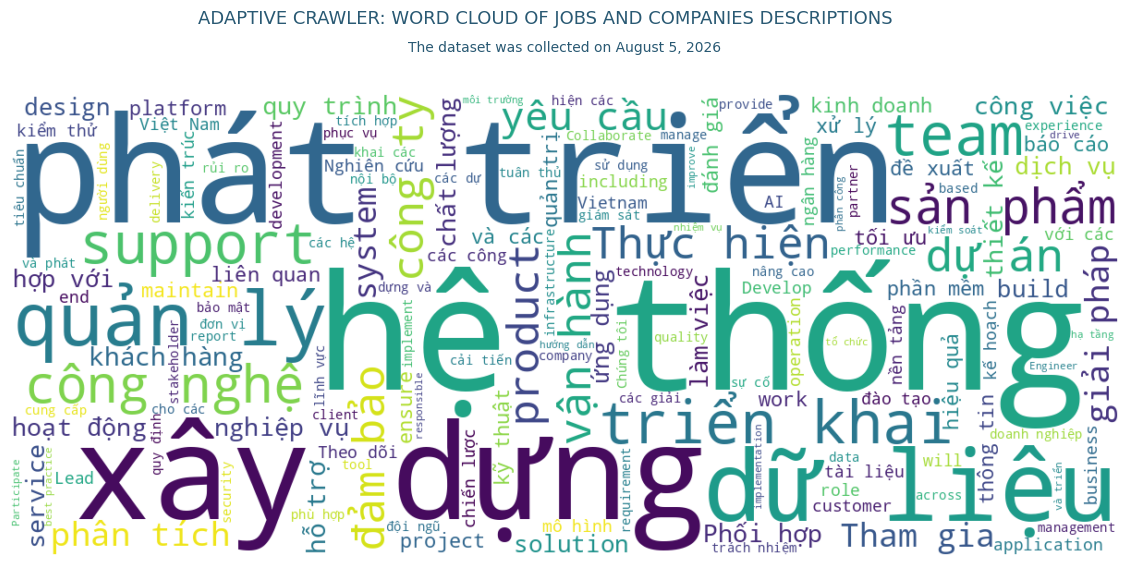

In [131]:
job_text = " ".join(jobs_df['job_description'].dropna().astype(str))
comp_text = " ".join(companies_df['description'].dropna().astype(str))
combined_text = job_text + " " + comp_text

wordcloud = WordCloud(
    width=1200,
    height=500,
    background_color='white',
    max_words=150,
    stopwords=STOPWORDS
).generate(combined_text)

plt.figure(figsize=(15, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.suptitle(
    'ADAPTIVE CRAWLER: WORD CLOUD OF JOBS AND COMPANIES DESCRIPTIONS',
    fontsize=13,
    color="#295973",
    y=1.02
)

plt.title(
    'The dataset was collected on August 5, 2026',
    fontsize=10,
    color="#295973",
    pad=30
)

plt.show()

In [132]:
job_lens = jobs_df['vector_context'].dropna().astype(str).str.split().str.len()
comp_lens = companies_df['vector_context'].dropna().astype(str).str.split().str.len()
doc_lengths = pd.concat([job_lens, comp_lens], ignore_index=True)

merged_skills = pd.merge(skills_jobs_df, skills_df, left_on='skill_id', right_on='id', how='inner')
top_skills = merged_skills['name'].value_counts().head(15)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Vector Context Length Distribution", "Top 15 Most Frequent Skills"),
    horizontal_spacing=0.1
)

fig.add_trace(
    go.Histogram(
        x=doc_lengths,
        nbinsx=50,
        name="Word Count",
        marker_color='#3366CC',
        opacity=0.75
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=top_skills.values[::-1],
        y=top_skills.index[::-1],
        orientation='h',
        name="Skill Frequency",
        marker_color='#DC3912'
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="Number of Words", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_xaxes(title_text="Number of Job Postings", row=1, col=2)
fig.update_yaxes(title_text="Skill", row=1, col=2)

fig.update_layout(
    height=600,
    margin=dict(t=150),
    showlegend=False,
    title_text="ADAPTIVE CRAWLER: VECTOR CONTEXT LENGTH AND SKILL DISTRIBUTIONS <br> <sub>The dataset was collected on August 5, 2026</sub>",
    template="plotly_white",
    title_x=0.5,
    title_font_color="#295973",
)

fig.show()

In [133]:
jobs_df['created_date'] = pd.to_datetime(jobs_df['created_date'])
df_sorted = jobs_df.sort_values('created_date').copy()
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_sorted['created_date'],
        y=df_sorted['cumulative_count'],
        mode='lines',
        line=dict(color='#3366CC', width=3),
        fill='tozeroy',
        fillcolor='rgba(51, 102, 204, 0.2)'
    )
)

fig.update_layout(
    margin=dict(t=120),
    title_text="ADAPTIVE CRAWLER: JOB CRAWLING PROGRESS OVER TIME <br> <sub>The crawler is using the UTC timezone on August 5, 2026</sub>",
    title_x=0.5,
    title_font_color="#295973",
    font=dict(family="Arial, sans-serif"),
    xaxis_title="Timeline",
    yaxis_title="Total Jobs Crawled",
    height=500,
    showlegend=False,
    template="plotly_white"
)

fig.show()

In [140]:
df_merged = pd.merge(skills_jobs_df, skills_df, left_on='skill_id', right_on='id').dropna(subset=['name'])
job_skills = df_merged.groupby('job_id')['name'].apply(list)

co_occurrences = Counter()
for skills in job_skills:
    if len(skills) > 1:
        co_occurrences.update(combinations(sorted(skills), 2))

top_edges = co_occurrences.most_common(100)

G = nx.Graph()
for (skill1, skill2), weight in top_edges:
    G.add_edge(skill1, skill2, weight=weight)

pos = nx.spring_layout(G, k=0.3, iterations=50, seed=42)

edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1, color='#888'),
    hoverinfo='none',
    mode='lines'
)

node_x = []
node_y = []
node_text = []
node_adjacencies = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    node_adjacencies.append(G.degree(node))

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_text,
    textposition="top center",
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        reversescale=True,
        color=node_adjacencies,
        size=[(deg * 1.5) + 10 for deg in node_adjacencies],
        colorbar=dict(
            thickness=15,
            title='Connections',
            xanchor='left',
            titleside='right'
        ),
        line_width=2
    )
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    margin=dict(t=120, b=20, l=20, r=20),
    title_text="ADAPTIVE CRAWLER: SKILL CO-OCCURRENCE NETWORK <br> <sub>Visualizing the Top 100 strongest skill connections across job postings</sub>",
    title_x=0.5,
    title_font_color="#295973",
    font=dict(family="Arial, sans-serif"),
    height=750,
    showlegend=False,
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()